In [3]:
# Install if needed:
# !pip install pandas numpy seaborn matplotlib plotly statsmodels scikit-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import timedelta

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)


In [4]:
# Replace with your actual file name
df = pd.read_csv("traffic.csv")  # columns: DateTime, Junction, Vehicles, ID

# Basic checks
df.head(), df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


(              DateTime  Junction  Vehicles           ID
 0  2015-11-01 00:00:00         1        15  20151101001
 1  2015-11-01 01:00:00         1        13  20151101011
 2  2015-11-01 02:00:00         1        10  20151101021
 3  2015-11-01 03:00:00         1         7  20151101031
 4  2015-11-01 04:00:00         1         9  20151101041,
 None,
            Junction      Vehicles            ID
 count  48120.000000  48120.000000  4.812000e+04
 mean       2.180549     22.791334  2.016330e+10
 std        0.966955     20.750063  5.944854e+06
 min        1.000000      1.000000  2.015110e+10
 25%        1.000000      9.000000  2.016042e+10
 50%        2.000000     15.000000  2.016093e+10
 75%        3.000000     29.000000  2.017023e+10
 max        4.000000    180.000000  2.017063e+10)

In [5]:
# Parse datetime and sort
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values(["Junction", "DateTime"]).reset_index(drop=True)

# Time features
df["hour"] = df["DateTime"].dt.hour
df["dayofweek"] = df["DateTime"].dt.dayofweek  # Monday=0
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["is_peak"] = df["hour"].isin([7,8,9,17,18,19]).astype(int)  # simple peak assumption

# Optional cyclic encoding for hour/day (helps models capture periodicity)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

In [6]:
scaler = StandardScaler()
df["Vehicles_norm"] = scaler.fit_transform(df[["Vehicles"]])


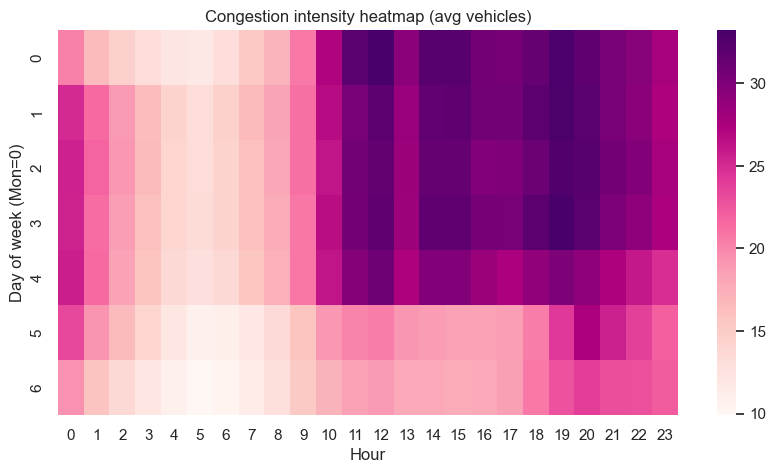

In [7]:
# Vehicles over time by junction
fig = px.line(df, x="DateTime", y="Vehicles", color="Junction",
              title="Hourly vehicles by junction")
fig.show()

# Average vehicles by hour and junction
hourly = df.groupby(["Junction", "hour"])["Vehicles"].mean().reset_index()
fig = px.line(hourly, x="hour", y="Vehicles", color="Junction",
              title="Average vehicles per hour by junction")
fig.show()

# Heatmap: congestion intensity (avg vehicles) by day-of-week and hour
pivot = df.pivot_table(index="dayofweek", columns="hour", values="Vehicles", aggfunc="mean")
sns.heatmap(pivot, cmap="RdPu")
plt.title("Congestion intensity heatmap (avg vehicles)")
plt.ylabel("Day of week (Mon=0)")
plt.xlabel("Hour")
plt.show()

In [8]:
# Define peak threshold per junction: top 20% hours by vehicles
def label_peaks(group, quantile=0.8):
    thr = group["Vehicles"].quantile(quantile)
    group["is_peak_data"] = (group["Vehicles"] >= thr).astype(int)
    return group

df = df.groupby("Junction", group_keys=False).apply(label_peaks)

# Compare model-based is_peak vs data-based
peak_compare = df.groupby("Junction")[["is_peak", "is_peak_data"]].mean().rename(
    columns={"is_peak":"peak_rule_rate","is_peak_data":"peak_data_rate"}
)
peak_compare

C:\Users\megha\AppData\Local\Temp\ipykernel_17640\465723591.py:7: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,peak_rule_rate,peak_data_rate
Junction,,
1,0.25,0.206414
2,0.25,0.209841
3,0.25,0.224301
4,0.25,0.223297


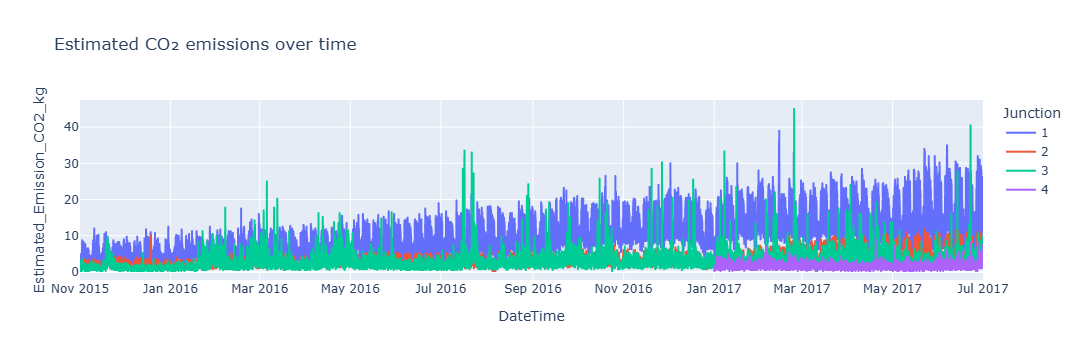

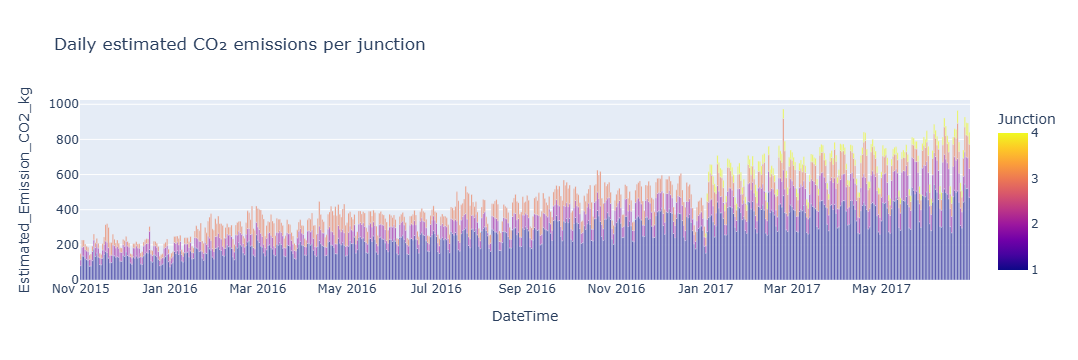

In [9]:
# Choose a simple emission factor (kg CO2 per vehicle per hour)
EMISSION_FACTOR_CO2 = 0.25  # adjust in sensitivity analysis

df["Estimated_Emission_CO2_kg"] = df["Vehicles"] * EMISSION_FACTOR_CO2

# Emission trends
fig = px.line(df, x="DateTime", y="Estimated_Emission_CO2_kg", color="Junction",
              title="Estimated CO₂ emissions over time")
fig.show()

# Daily totals per junction
daily_emissions = df.set_index("DateTime").groupby("Junction")["Estimated_Emission_CO2_kg"] \
    .resample("D").sum().reset_index()
fig = px.bar(daily_emissions, x="DateTime", y="Estimated_Emission_CO2_kg", color="Junction",
             title="Daily estimated CO₂ emissions per junction")
fig.show()

Adaptive signal control — peak emissions change: 11.86%


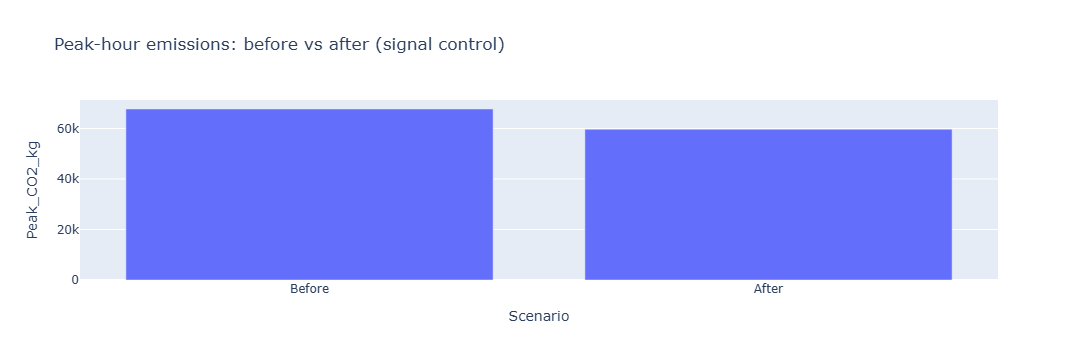

In [12]:
# Identify top congested junctions by mean vehicles during peak hours
peak_df = df[df["is_peak"] == 1]
mean_peak = peak_df.groupby("Junction")["Vehicles"].mean().sort_values(ascending=False)
top_junctions = mean_peak.index[:2].tolist()  # choose top 2

# Policy: reduce vehicles by 15% during peak at top junctions (proxy for improved flow)
policy_reduction = 0.15

df_sim_signal = df.copy()
mask = (df_sim_signal["is_peak"] == 1) & (df_sim_signal["Junction"].isin(top_junctions))
df_sim_signal.loc[mask, "Vehicles"] = (df_sim_signal.loc[mask, "Vehicles"] * (1 - policy_reduction)).round()

df_sim_signal["Estimated_Emission_CO2_kg"] = df_sim_signal["Vehicles"] * EMISSION_FACTOR_CO2

# Compare emissions before vs after (peak hours)
before_peak_emissions = df[df["is_peak"]==1]["Estimated_Emission_CO2_kg"].sum()
after_peak_emissions = df_sim_signal[df_sim_signal["is_peak"]==1]["Estimated_Emission_CO2_kg"].sum()
reduction_pct = 100 * (before_peak_emissions - after_peak_emissions) / before_peak_emissions

print(f"Adaptive signal control — peak emissions change: {reduction_pct:.2f}%")

fig = px.bar(
    pd.DataFrame({
        "Scenario": ["Before", "After"],
        "Peak_CO2_kg": [before_peak_emissions, after_peak_emissions]
    }),
    x="Scenario", y="Peak_CO2_kg", title="Peak-hour emissions: before vs after (signal control)"
)
fig.show()

In [13]:
# Identify hotspot junction (highest overall mean vehicles)
hotspot = df.groupby("Junction")["Vehicles"].mean().idxmax()

# Redistribute 10% of hotspot traffic to other junctions during peak
redistribute_pct = 0.10
others = [j for j in df["Junction"].unique() if j != hotspot]

df_sim_redistrib = df.copy()
mask_hotspot_peak = (df_sim_redistrib["is_peak"]==1) & (df_sim_redistrib["Junction"]==hotspot)

# Reduce hotspot
df_sim_redistrib.loc[mask_hotspot_peak, "Vehicles"] = (
    df_sim_redistrib.loc[mask_hotspot_peak, "Vehicles"] * (1 - redistribute_pct)
).round()

# Increase others proportionally (even split)
if len(others) > 0:
    increment_per_other = redistribute_pct / len(others)
    mask_others_peak = (df_sim_redistrib["is_peak"]==1) & (df_sim_redistrib["Junction"].isin(others))
    df_sim_redistrib.loc[mask_others_peak, "Vehicles"] = (
        df_sim_redistrib.loc[mask_others_peak, "Vehicles"] * (1 + increment_per_other)
    ).round()

df_sim_redistrib["Estimated_Emission_CO2_kg"] = df_sim_redistrib["Vehicles"] * EMISSION_FACTOR_CO2

# Evaluate net emissions change during peak
before_peak = df[df["is_peak"]==1]["Estimated_Emission_CO2_kg"].sum()
after_peak = df_sim_redistrib[df_sim_redistrib["is_peak"]==1]["Estimated_Emission_CO2_kg"].sum()
net_change_pct = 100 * (after_peak - before_peak) / before_peak

print(f"Traffic redistribution — net peak emissions change: {net_change_pct:.2f}%")

Traffic redistribution — net peak emissions change: -4.97%


In [14]:
# Congestion index proxy: mean vehicles during peak
congestion_before = df[df["is_peak"]==1]["Vehicles"].mean()
congestion_signal = df_sim_signal[df_sim_signal["is_peak"]==1]["Vehicles"].mean()
congestion_redistrib = df_sim_redistrib[df_sim_redistrib["is_peak"]==1]["Vehicles"].mean()

print("Congestion (peak mean vehicles):")
print(f"- Before: {congestion_before:.2f}")
print(f"- Signal control: {congestion_signal:.2f}")
print(f"- Redistribution: {congestion_redistrib:.2f}")

# Emission totals
total_emissions_before = df["Estimated_Emission_CO2_kg"].sum()
total_emissions_signal = df_sim_signal["Estimated_Emission_CO2_kg"].sum()
total_emissions_redistrib = df_sim_redistrib["Estimated_Emission_CO2_kg"].sum()

print("Total emissions (kg CO2):")
print(f"- Before: {total_emissions_before:.2f}")
print(f"- Signal control: {total_emissions_signal:.2f} ({100*(total_emissions_before-total_emissions_signal)/total_emissions_before:.2f}% reduction)")
print(f"- Redistribution: {total_emissions_redistrib:.2f} ({100*(total_emissions_before-total_emissions_redistrib)/total_emissions_before:.2f}% reduction)")

Congestion (peak mean vehicles):
- Before: 22.51
- Signal control: 19.84
- Redistribution: 21.40
Total emissions (kg CO2):
- Before: 274179.75
- Signal control: 266149.25 (2.93% reduction)
- Redistribution: 270816.00 (1.23% reduction)


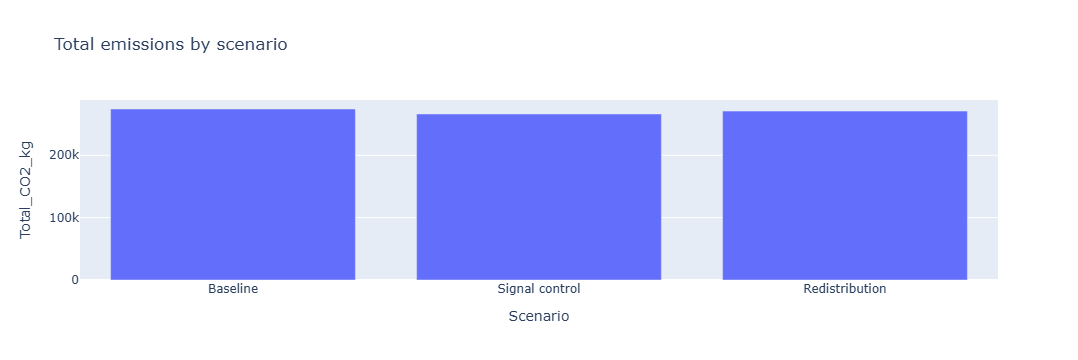

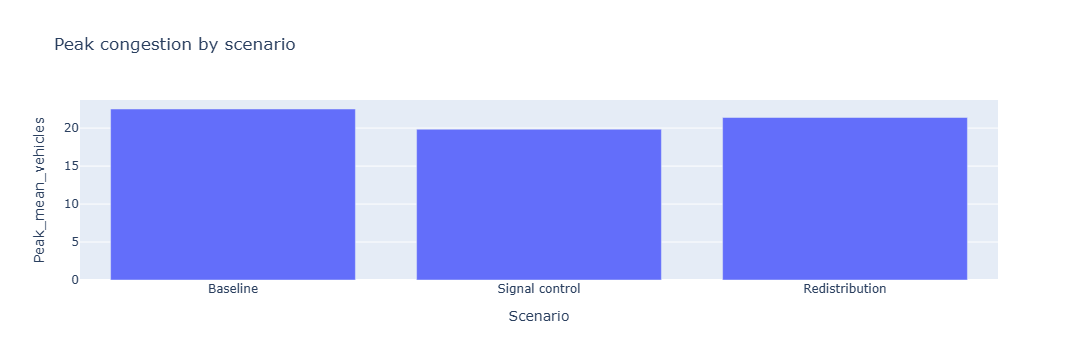

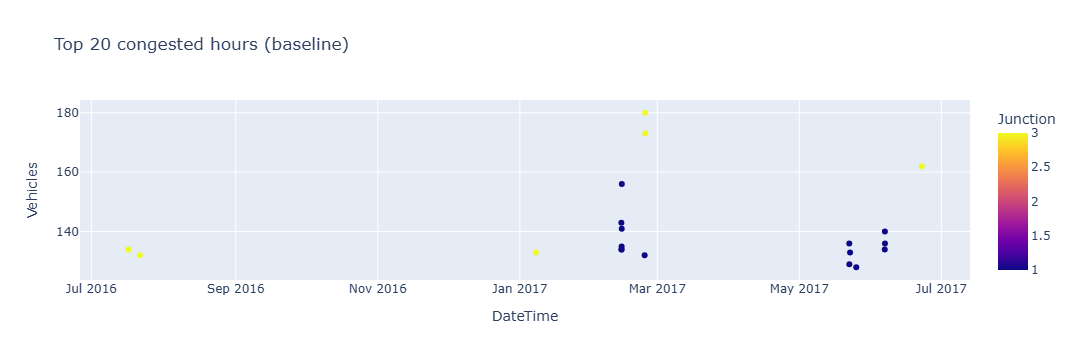

In [15]:
# Summary KPIs
summary = pd.DataFrame({
    "Scenario": ["Baseline", "Signal control", "Redistribution"],
    "Total_CO2_kg": [total_emissions_before, total_emissions_signal, total_emissions_redistrib],
    "Peak_mean_vehicles": [congestion_before, congestion_signal, congestion_redistrib]
})

fig = px.bar(summary, x="Scenario", y="Total_CO2_kg", title="Total emissions by scenario")
fig.show()

fig = px.bar(summary, x="Scenario", y="Peak_mean_vehicles", title="Peak congestion by scenario")
fig.show()

# Hotspots (top hours)
top_hours = df.sort_values("Vehicles", ascending=False).head(20)
fig = px.scatter(top_hours, x="DateTime", y="Vehicles", color="Junction",
                 title="Top 20 congested hours (baseline)", hover_data=["ID"])
fig.show()

In [16]:
def evaluate_emission_factor(ef):
    temp = df.copy()
    temp["Estimated_Emission_CO2_kg"] = temp["Vehicles"] * ef
    return temp["Estimated_Emission_CO2_kg"].sum()

for ef in [0.20, 0.25, 0.30]:
    total = evaluate_emission_factor(ef)
    print(f"EF={ef:.2f} kg/veh-h -> Total CO2={total:.2f} kg")

EF=0.20 kg/veh-h -> Total CO2=219343.80 kg
EF=0.25 kg/veh-h -> Total CO2=274179.75 kg
EF=0.30 kg/veh-h -> Total CO2=329015.70 kg
